<a href="https://colab.research.google.com/github/berkayagrdmr/TCSG-POYRAZ-Resistance-and-Propulsion-Analysis/blob/main/normalgrafik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

-------------------------------------------------------
V (kn)   | Fn       | R_Total (kN)   | PE (kW)       
-------------------------------------------------------
5.0      | 0.1186   | 7.91           | 20.34         
6.0      | 0.1423   | 11.05          | 34.11         
7.0      | 0.1660   | 14.70          | 52.94         
8.0      | 0.1897   | 18.99          | 78.15         
9.0      | 0.2134   | 24.14          | 111.79        
10.0     | 0.2371   | 30.49          | 156.85        
11.0     | 0.2608   | 38.23          | 216.35        
12.0     | 0.2845   | 49.09          | 303.07        
13.0     | 0.3082   | 61.44          | 410.91        
14.0     | 0.3320   | 71.83          | 517.36        
15.0     | 0.3557   | 83.56          | 644.79        
16.0     | 0.3794   | 101.89         | 838.64        
17.0     | 0.4031   | 130.10         | 1137.83       
18.0     | 0.4268   | 156.08         | 1445.25       
19.0     | 0.4505   | 181.99         | 1778.79       
20.0     | 0.4742   | 20

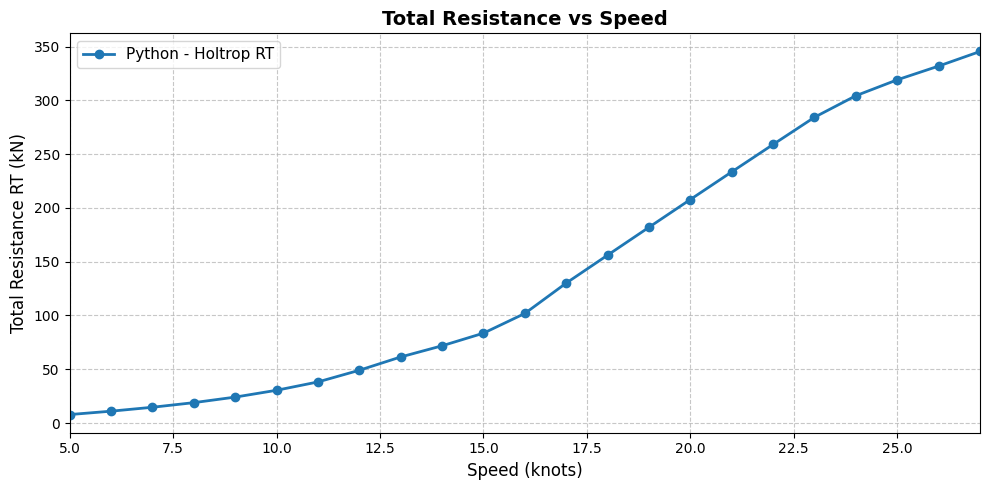

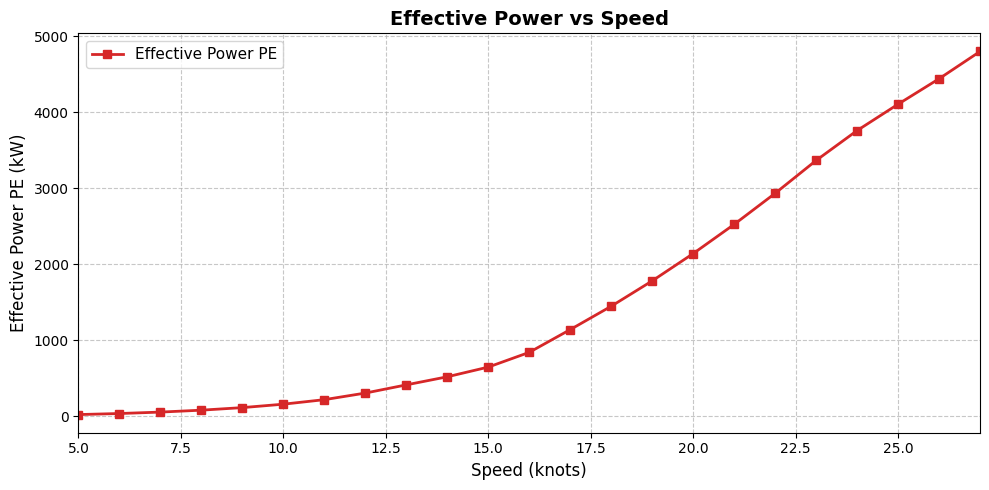

In [ ]:
import math
import matplotlib.pyplot as plt

# ==============================================================================
# 1. TASARIM PARAMETRELERI (KENDI DEGERLERINIZI BURAYA GIRINIZ)
# ==============================================================================
L       = 48   # Su hatti boyu (m)
B       = 9.0   # Kalip genisligi (m)
T_F     = 2.5   # Bas draft (m)
T_A     = 2.5   # Kic draft (m)
disp    = 470.75   # Deplasman hacmi (m^3)
C_B     = 0.48   # Blok katsayisi
C_P     = 0.659   # Prizmatik katsayi
C_M     = 0.746   # Orta kesit katsayisi
C_WP    = 0.803   # Su hatti alan katsayisi
lcb     = -2.24   # Yuzdurme merkezi boyuna konumu (L'nin %'si olarak)
A_T     = 5.772   # Batan transom alani (Aciniz su ustunde oldugu icin 0.0 girin)
A_BT    = 0.0   # Bodoslama enkesit alani (Yoksa 0.0 girin)
h_B     = 1.5   # Bodoslama alani merkezinin yuksekligi (Yoksa 0.0 girin)
C_stern = 0.0  # Kic form katsayisi (Normal: 0, V-sekilli: -10, vs.)
S_APP   = 0.0   # Ek takilarin islak alani (m^2)
k2_eq   = 1.5   # Esdeger ek taki direnc faktoru (1+k2) (Orn: 1.5, yoksa 1.0)
i_E     = None   # Yarim giris acisi (derece). Bilinmiyorsa None birakabilirsiniz.


# ==============================================================================
# 2. HOLTROP & MENNEN HESAPLAMA FONKSIYONU
# ==============================================================================
def calculate_holtrop_mennen(V_knots, L, B, T_F, T_A, disp, C_B, C_P, C_M, C_WP, lcb, A_T, A_BT, h_B, C_stern, S_APP, k2_eq, i_E):
    V = V_knots * 0.51444
    g = 9.80665
    rho = 1025.0
    nu = 1.18831e-6
    T = (T_F + T_A) / 2.0

    F_n = V / math.sqrt(g * L)

    term_S1 = 0.453 + 0.4425 * C_B - 0.2862 * C_M - 0.003467 * (B / T) + 0.3696 * C_WP
    term_S2 = 2.38 * A_BT / C_B if C_B != 0 else 0
    S = L * (2 * T + B) * math.sqrt(C_M) * term_S1 + term_S2

    Re = V * L / nu
    C_F = 0.075 / (math.log10(Re) - 2)**2
    R_F = 0.5 * rho * V**2 * S * C_F

    L_R = L * (1 - C_P + 0.06 * C_P * lcb / (4 * C_P - 1))
    c_14 = 1 + 0.011 * C_stern
    term_k1 = 0.487118 * c_14 * (B / L)**1.06806 * (T / L)**0.46106 * (L / L_R)**0.121563 * (L**3 / disp)**0.36486 * (1 - C_P)**-0.604247
    one_plus_k1 = 0.93 + term_k1

    R_APP = 0.5 * rho * V**2 * S_APP * k2_eq * C_F

    if A_BT > 0:
        c_3 = 0.56 * A_BT**1.5 / (B * T * (0.31 * math.sqrt(A_BT) + T_F - h_B))
    else:
        c_3 = 0.0

    c_2 = math.exp(-1.89 * math.sqrt(c_3))
    c_5 = 1 - 0.8 * A_T / (B * T * C_M)
    d = -0.9

    if L / B < 12:
        lamb = 1.446 * C_P - 0.03 * (L / B)
    else:
        lamb = 1.446 * C_P - 0.36

    disp_ratio = L**3 / disp
    if disp_ratio < 512:
        c_15 = -1.69385
    elif 512 <= disp_ratio <= 1726.91:
        c_15 = -1.69385 + (L / (disp**(1/3)) - 8.0) / 2.36
    else:
        c_15 = 0.0

    m_4 = c_15 * 0.4 * math.exp(-0.034 * F_n**-3.29)

    if i_E is None:
        term_iE = -(L / B)**0.80856 * (1 - C_WP)**0.30484 * (1 - C_P - 0.0225 * lcb)**0.6367 * (L_R / B)**0.34574 * (100 * disp / L**3)**0.16302
        i_E = 1 + 89 * math.exp(term_iE)

    def calculate_R_W_A(Fn_val):
        if B / L < 0.11:
            c_7 = 0.229577 * (B / L)**0.33333
        elif 0.11 <= B / L <= 0.25:
            c_7 = B / L
        else:
            c_7 = 0.5 - 0.0625 * (L / B)
        c_1 = 2223105 * c_7**3.78613 * (T / B)**1.07961 * (90 - i_E)**-1.37565
        if C_P < 0.8:
            c_16 = 8.07981 * C_P - 13.8673 * C_P**2 + 6.984388 * C_P**3
        else:
            c_16 = 1.73014 - 0.7067 * C_P
        m_1 = 0.0140407 * (L / T) - 1.75254 * (disp**(1/3) / L) - 4.79323 * (B / L) - c_16
        m_4_local = c_15 * 0.4 * math.exp(-0.034 * Fn_val**-3.29)
        return c_1 * c_2 * c_5 * disp * rho * g * math.exp(m_1 * Fn_val**d + m_4_local * math.cos(lamb * Fn_val**-2))

    def calculate_R_W_B(Fn_val):
        c_17 = 6919.3 * C_M**-1.3346 * (disp / L**3)**2.00977 * (L / B - 2)**1.40692
        m_3 = -7.2035 * (B / L)**0.326869 * (T / B)**0.605375
        m_4_local = c_15 * 0.4 * math.exp(-0.034 * Fn_val**-3.29)
        return c_17 * c_2 * c_5 * disp * rho * g * math.exp(m_3 * Fn_val**d + m_4_local * math.cos(lamb * Fn_val**-2))

    if F_n <= 0.40:
        R_W = calculate_R_W_A(F_n)
    elif F_n >= 0.55:
        R_W = calculate_R_W_B(F_n)
    else:
        R_W_A_04 = calculate_R_W_A(0.40)
        R_W_B_055 = calculate_R_W_B(0.55)
        R_W = R_W_A_04 + (10 * F_n - 4) * (R_W_B_055 - R_W_A_04) / 1.5

    if A_BT > 0:
        P_B = 0.56 * math.sqrt(A_BT) / (T_F - 1.5 * h_B)
        F_ni = V / math.sqrt(g * (T_F - h_B - 0.25 * math.sqrt(A_BT)) + 0.15 * V**2)
        R_B = 0.11 * math.exp(-3 * P_B**-2) * F_ni**3 * A_BT**1.5 * rho * g / (1 + F_ni**2)
    else:
        R_B = 0.0

    if A_T > 0:
        F_nT = V / math.sqrt(2 * g * A_T / (B + B * C_WP))
        if F_nT < 5:
            c_6 = 0.2 * (1 - 0.2 * F_nT)
        else:
            c_6 = 0.0
        R_TR = 0.5 * rho * V**2 * A_T * c_6
    else:
        R_TR = 0.0

    if T_F / L <= 0.04:
        c_4 = T_F / L
    else:
        c_4 = 0.04

    C_A = 0.006 * (L + 100)**-0.16 - 0.00205 + 0.003 * math.sqrt(L / 7.5) * C_B**4 * c_2 * (0.04 - c_4)
    R_A = 0.5 * rho * V**2 * S * C_A

    R_total = R_F * one_plus_k1 + R_APP + R_W + R_B + R_TR + R_A

    return {
        "R_Total (kN)": R_total / 1000
    }

# ==============================================================================
# 3. HIZ DONGUSU, TABLO OLUSTURMA VE GRAFIK CIZIMI
# ==============================================================================
try:
    hizlar = range(5, 28)
    rt_degerleri = []
    pe_degerleri = []

    # Raporunuza kopyalayabileceginiz sonuc tablosu basligi
    print("-" * 55)
    print(f"{'V (kn)':<8} | {'Fn':<8} | {'R_Total (kN)':<14} | {'PE (kW)':<14}")
    print("-" * 55)

    for v in hizlar:
        # Her bir hiz icin dongu icinde hesaplama
        sonuc = calculate_holtrop_mennen(
            v, L, B, T_F, T_A, disp, C_B, C_P, C_M, C_WP, lcb, A_T, A_BT, h_B, C_stern, S_APP, k2_eq, i_E
        )

        Fn = v * 0.51444 / math.sqrt(9.80665 * L)
        rt = sonuc["R_Total (kN)"]

        # Efektif Guc Hesabi: PE (kW) = R_Total (kN) * V (m/s)
        v_ms = v * 0.51444
        pe = rt * v_ms

        rt_degerleri.append(rt)
        pe_degerleri.append(pe)

        # Tablo satirlarini yazdirma
        print(f"{v:<8.1f} | {Fn:<8.4f} | {rt:<14.2f} | {pe:<14.2f}")

    print("-" * 55)

    # Grafik 1: Direnc (Resistance)
    plt.figure(figsize=(10, 5))
    plt.plot(hizlar, rt_degerleri, marker='o', linestyle='-', color='#1f77b4', linewidth=2, label='Python - Holtrop RT')
    plt.title('Total Resistance vs Speed', fontsize=14, fontweight='bold')
    plt.xlabel('Speed (knots)', fontsize=12)
    plt.ylabel('Total Resistance RT (kN)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=11)
    plt.xlim(5, 27)
    plt.tight_layout()
    plt.show()

    # Grafik 2: Guc (Power)
    plt.figure(figsize=(10, 5))
    plt.plot(hizlar, pe_degerleri, marker='s', linestyle='-', color='#d62728', linewidth=2, label='Effective Power PE')
    plt.title('Effective Power vs Speed', fontsize=14, fontweight='bold')
    plt.xlabel('Speed (knots)', fontsize=12)
    plt.ylabel('Effective Power PE (kW)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=11)
    plt.xlim(5, 27)
    plt.tight_layout()
    plt.show()

except TypeError:
    print("LUTFEN DIKKAT: 'TASARIM PARAMETRELERI' kismindaki 'None' degerlerini kendi sayisal degerlerinizle degistirin.")
except Exception as e:
    print(f"Hesaplama sirasinda bir hata olustu: {e}")